# 勇者傳說 — Decoration V2 Generator (T4 GPU)

Generate **AI pixel art decorations** for towns and fields using SDXL + pixel-art-xl LoRA.

| Category | Count | Steps | Guidance |
|----------|-------|-------|----------|
| Kingdom decorations | 19 | 22 | 7.5 |
| Seamless path tile | 1 | 25 | 7.0 |
| **Total** | **20** | | |

**Self-contained**: No repo clone needed.  
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`  
**Resume**: 中斷後重跑自動跳過已完成的

In [2]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0

In [3]:
from PIL import Image
import numpy as np


class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')


_rmbg_model = None
_rembg_session = None


def remove_background(img):
    """Remove background using RMBG-2.0 (primary) + rembg u2net (fallback)."""
    global _rmbg_model, _rembg_session

    # Primary: RMBG-2.0
    try:
        if _rmbg_model is None:
            from transformers import pipeline
            _rmbg_model = pipeline('image-segmentation',
                                   model='briaai/RMBG-2.0',
                                   trust_remote_code=True,
                                   device=0 if torch.cuda.is_available() else -1)
        result = _rmbg_model(img)
        if isinstance(result, list):
            mask = result[0]['mask']
        else:
            mask = result['mask']
        img = img.convert('RGBA')
        img.putalpha(mask.convert('L'))
        return img
    except Exception as e:
        print(f'[warn] RMBG-2.0 failed: {e}, trying rembg...')

    # Fallback: rembg u2net
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def quality_check(img):
    """Check if generated image has enough visible content."""
    arr = np.array(img.convert('RGBA'))
    alpha = arr[:, :, 3]
    visible_ratio = np.sum(alpha > 10) / alpha.size
    if visible_ratio < 0.02:
        print(f'[quality] too sparse ({visible_ratio:.1%})', end=' ')
        return False
    return True

In [4]:
PROMPTS = {
    '_meta': {
        'style_prefix_xl': '16-bit JRPG pixel art, top-down RPG decoration object',
        'style_suffix_deco_xl': 'single object centered, transparent background, clean edges, detailed pixel art sprite',
        'negative_prompt_xl': 'blurry, modern, text, UI, photograph, realistic photo, people, characters, watermark, multiple objects',
    },
    'decorations': [
        # Hero kingdom
        {'name': 'deco_training_dummy', 'prompt_xl': 'wooden sword training dummy practice target, straw filled, medieval training ground equipment', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Elf kingdom
        {'name': 'deco_vine_arch', 'prompt_xl': 'living vine archway gate covered in green leaves and flowers, elven forest entrance arch', 'gen_size': 256, 'final_w': 64, 'final_h': 96, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_hanging_lantern', 'prompt_xl': 'ornate hanging lantern with warm glow, metal and glass elven style lantern on chain', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Treant kingdom
        {'name': 'deco_ancient_tree', 'prompt_xl': 'massive ancient sacred tree with glowing runes carved in bark, giant mystical oak tree, hollow trunk', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_mushroom_large', 'prompt_xl': 'giant glowing bioluminescent mushroom, spotted cap, fantasy forest mushroom, purple and blue glow', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Beast kingdom
        {'name': 'deco_fire_pit', 'prompt_xl': 'blazing stone fire pit campfire with flames, tribal stone ring bonfire, warm orange glow', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_totem', 'prompt_xl': 'tall carved wooden totem pole with animal faces, tribal spirit totem, painted colors', 'gen_size': 256, 'final_w': 64, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_arena', 'prompt_xl': 'fighting arena ground marking circle with torches, combat ring, tribal battle arena floor from above', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        # Merfolk kingdom
        {'name': 'deco_canal_bridge', 'prompt_xl': 'ornate small stone canal bridge over water, arched bridge with coral decorations, aquatic town bridge', 'gen_size': 256, 'final_w': 128, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_dock', 'prompt_xl': 'wooden dock pier extending over water, fishing dock with rope and posts, seaside pier', 'gen_size': 256, 'final_w': 128, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Dwarf kingdom
        {'name': 'deco_crystal', 'prompt_xl': 'glowing crystal cluster formation, purple and blue mineral crystals growing from rock, gem deposit', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_mine_entrance_sm', 'prompt_xl': 'small mine shaft entrance in rock wall, wooden support beams, minecart track, dark tunnel opening', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        # Undead kingdom
        {'name': 'deco_gravestone', 'prompt_xl': 'weathered old tombstone gravestone, cracked stone with moss, cemetery headstone, eerie green glow', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Volcano kingdom
        {'name': 'deco_lava_vent', 'prompt_xl': 'volcanic steam vent crack in ground, hot gas and ember particles rising, lava glow from below', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Hotspring kingdom
        {'name': 'deco_bamboo_fence', 'prompt_xl': 'Japanese bamboo fence section, woven bamboo barrier, garden divider, zen style bamboo wall', 'gen_size': 256, 'final_w': 128, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_stone_lantern', 'prompt_xl': 'Japanese stone lantern toro, traditional garden stone lantern, warm light, zen garden element', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Mountain kingdom
        {'name': 'deco_prayer_flag', 'prompt_xl': 'colorful Tibetan prayer flags on string line, fluttering cloth flags, mountain temple prayer flags', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_cairn', 'prompt_xl': 'stacked stone cairn rock pile, balanced stones trail marker, mountain path stone pile', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Demon kingdom
        {'name': 'deco_rune_circle', 'prompt_xl': 'dark magical rune circle on ground, glowing red arcane symbols in circle pattern, demonic summoning circle', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
    ],
    'tiles': [
        # Generic path tile (seamless)
        {'name': 'tile_path', 'prompt_xl': 'cobblestone path road texture, worn stone bricks, medieval road surface, seamless tileable', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 25, 'guidance': 7.0, 'seamless': True},
    ],
}

print(f"Decorations: {len(PROMPTS['decorations'])}")
print(f"Tiles: {len(PROMPTS['tiles'])}")
print(f"Total: {len(PROMPTS['decorations']) + len(PROMPTS['tiles'])}")

Decorations: 19
Tiles: 1
Total: 20


In [5]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE})...')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.85])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.85)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL (cuda)...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.85)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[pipeline] Cached to /content/drive/MyDrive/ai-rpg-game/models/stable-diffusion-xl-base-1.0
[pipeline] Ready in 318.0s
[vram] 6.7/14.6 GB


In [6]:
def postprocess_deco(img, entry):
    """Remove background, crop, resize to target size."""
    final_w = entry['final_w']
    final_h = entry['final_h']

    img = remove_background(img.convert('RGBA'))

    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows_mask = np.any(alpha > 10, axis=1)
    cols_mask = np.any(alpha > 10, axis=0)
    if not rows_mask.any():
        return img.resize((final_w, final_h), Image.NEAREST)

    rmin, rmax = np.where(rows_mask)[0][[0, -1]]
    cmin, cmax = np.where(cols_mask)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    cw, ch = cropped.size
    scale = min(final_w / cw, final_h / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    canvas = Image.new('RGBA', (final_w, final_h), (0, 0, 0, 0))
    x = (final_w - new_w) // 2
    y = final_h - new_h  # bottom-align
    canvas.paste(resized, (x, y))
    return canvas


def generate_seamless_tile(entry, meta, out_dir, tracker):
    """Generate seamless tile using offset trick."""
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return

    prefix = meta['style_prefix_xl']
    suffix = meta.get('style_suffix_deco_xl', '')
    neg = meta['negative_prompt_xl']
    prompt = f"{prefix}, {entry['prompt_xl']}, seamless tileable texture, {suffix}"

    final_w = entry['final_w']
    final_h = entry['final_h']
    gen_size = entry['gen_size']

    print(f'  {name} (seamless, {gen_size}\u2192{final_w}x{final_h})...', end=' ')
    t0 = time.time()

    result = pipe(
        prompt=prompt, negative_prompt=neg + ', border, edge, frame',
        width=gen_size, height=gen_size,
        num_inference_steps=entry['steps'],
        guidance_scale=entry['guidance'],
    )
    raw = result.images[0]

    # Offset trick for seamless tiling
    w, h = raw.size
    offset_img = Image.new('RGB', (w, h))
    hw, hh = w // 2, h // 2
    # Swap quadrants
    offset_img.paste(raw.crop((hw, hh, w, h)), (0, 0))
    offset_img.paste(raw.crop((0, hh, hw, h)), (hw, 0))
    offset_img.paste(raw.crop((hw, 0, w, hh)), (0, hh))
    offset_img.paste(raw.crop((0, 0, hw, hh)), (hw, hh))

    # Run through pipeline again to blend seams
    from diffusers import StableDiffusionXLImg2ImgPipeline
    try:
        i2i_pipe = StableDiffusionXLImg2ImgPipeline(**pipe.components)
        blended = i2i_pipe(
            prompt=prompt, negative_prompt=neg,
            image=offset_img, strength=0.35,
            num_inference_steps=15, guidance_scale=entry['guidance'],
        ).images[0]
    except Exception:
        blended = offset_img

    # Resize to final
    final = blended.resize((final_w, final_h), Image.NEAREST)
    final.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'{kb:.0f} KB, {time.time()-t0:.1f}s')
    tracker.mark_done(name)
    free_vram()


# Generate decorations
entries = PROMPTS['decorations']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'decorations'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('decorations_v2', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nDecorations: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        continue

    prefix = meta['style_prefix_xl']
    suffix = meta['style_suffix_deco_xl']
    neg = meta['negative_prompt_xl']
    prompt = f"{prefix}, {entry['prompt_xl']}, {suffix}"

    print(f"[{i+1}/{len(entries)}] {name} ({entry['final_w']}x{entry['final_h']})...", end=' ')
    t0 = time.time()

    max_retries = 3
    for attempt in range(max_retries):
        seed = 42 + attempt * 1000
        generator = torch.Generator(device=DEVICE).manual_seed(seed)

        result = pipe(
            prompt=prompt, negative_prompt=neg,
            width=entry['gen_size'], height=entry['gen_size'],
            num_inference_steps=entry['steps'],
            guidance_scale=entry['guidance'],
            generator=generator,
        )
        img = postprocess_deco(result.images[0], entry)

        if quality_check(img):
            img.save(str(out_path), 'PNG')
            kb = out_path.stat().st_size / 1024
            print(f'{kb:.0f} KB, {time.time()-t0:.1f}s')
            tracker.mark_done(name)
            free_vram()
            break
        elif attempt < max_retries - 1:
            print(f'[retry {attempt+1}]', end=' ')
        else:
            img.save(str(out_path), 'PNG')
            kb = out_path.stat().st_size / 1024
            print(f'{kb:.0f} KB, {time.time()-t0:.1f}s [quality warning]')
            tracker.mark_done(name)
            free_vram()

print('\nDecorations done!')


Decorations: 19 total, 19 to generate
[1/19] deco_training_dummy (64x64)... 

  0%|          | 0/22 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
403 Client Error. (Request ID: Root=1-69ae2c8e-1d230e14190948991a24d2eb;d476455e-0c0d-4d56-b9da-d4f205c7ace0)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted and you are not in the authorized list. Visit https://huggingface.co/briaai/RMBG-2.0 to ask for access., trying rembg...


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

...

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
403 Client Error. (Request ID: Root=1-69ae2d7d-5a6beb5740690bb11329b946;9af140f7-9ee8-48fd-8998-eeb47e1feb3b)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted and you are not in the authorized list. Visit https://huggingface.co/briaai/RMBG-2.0 to ask for access., trying rembg...
4 KB, 9.0s
[18/19] deco_cairn (64x64)... 

  0%|          | 0/22 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
403 Client Error. (Request ID: Root=1-69ae2d87-1c7f432d32b9194b3d4d1f07;f46b0137-075e-40f9-bcbd-fb52a074dc6c)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted and you are not in the authorized list. Visit https://huggingface.co/briaai/RMBG-2.0 to ask for access., trying rembg...
5 KB, 9.8s
[19/19] deco_rune_circle (128x128)... 

  0%|          | 0/22 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
403 Client Error. (Request ID: Root=1-69ae2d91-753b7e260028644d37f96d61;93a52340-bee2-4d3b-831d-05ac36d29205)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted and you are not in the authorized list. Visit https://huggingface.co/briaai/RMBG-2.0 to ask for access., trying rembg...
12 KB, 9.6s

Decorations done!


  tile_path (seamless, 256→64x64)... 

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


8 KB, 10.3s

Tile generation done!


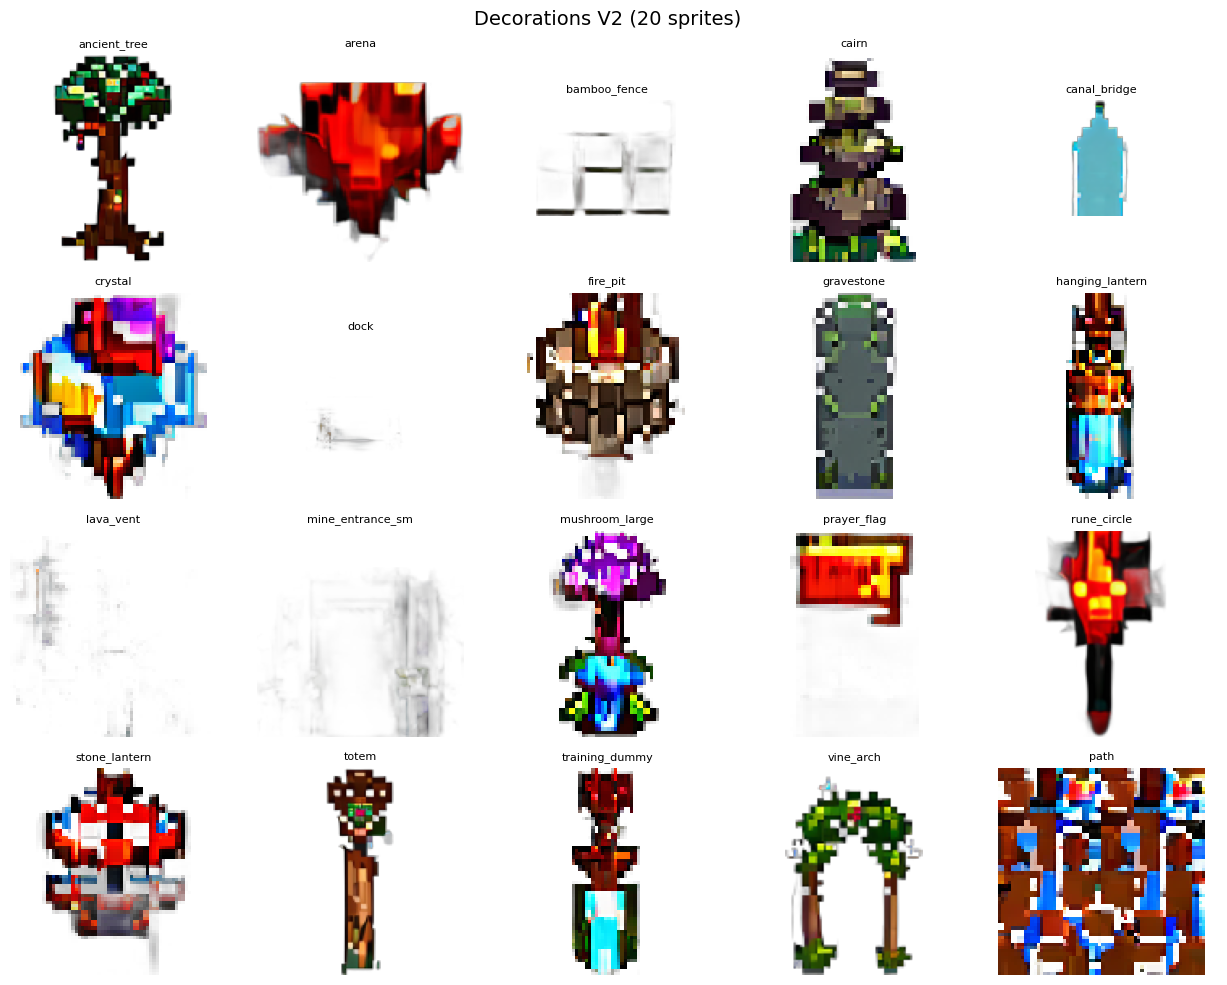

In [7]:
import matplotlib.pyplot as plt

# Generate seamless path tile
tile_entries = PROMPTS['tiles']
tile_out_dir = OUTPUT_BASE / 'decorations'  # same output dir
tile_out_dir.mkdir(parents=True, exist_ok=True)

tile_tracker = ProgressTracker('decorations_v2_tiles', OUTPUT_BASE)
for entry in tile_entries:
    generate_seamless_tile(entry, PROMPTS['_meta'], tile_out_dir, tile_tracker)

print('\nTile generation done!')

# Preview grid
out_dir = OUTPUT_BASE / 'decorations'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 5
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
if rows == 1:
    axes = [axes]
axes = np.atleast_2d(axes)
for ax in axes.flat:
    ax.axis('off')

for i, png in enumerate(pngs):
    ax = axes[i // cols][i % cols]
    img = Image.open(png)
    ax.imshow(img)
    ax.set_title(png.stem.replace('deco_', '').replace('tile_', ''), fontsize=8)

plt.suptitle(f'Decorations V2 ({len(pngs)} sprites)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'decorations'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['decorations'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/decorations_v2_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Manifest:
  decorations: 20

Zip: 42.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>